In [1]:
import os
notebookPath = os.path.dirname(os.path.dirname(os.getcwd()))

In [2]:
notebookPath

'/mnt/SATA/singleCellTaru'

In [3]:
import scanpy as sc
output_dir = os.path.join(notebookPath, "data", "new")
pastas = sorted(os.listdir(output_dir))

adatas = [sc.read_h5ad(os.path.join(output_dir, pastas[i])) for i in range(len(pastas))]

In [4]:
for adata in adatas:
    adata.var_names_make_unique()
    adata.obs_names_make_unique()

     dataset  n_cells  n_genes  total_reads  mean_reads_per_cell  \
0   CTH92_ML     1523    24293    7894346.0          5183.418457   
1   CTH92_NS      809    24397    8313809.0         10276.649414   
2   CTH94_ML      496    23630    6048679.0         12194.916992   
3   CTH94_NS     5558    29426   50007112.0          8997.321289   
4   CTH97_ML     4657    24340   15101780.0          3242.812988   
5   CTH97_NS     1502    26012   13392946.0          8916.741211   
6   HNP44_ML     1859    28391   27248874.0         14657.812500   
7   HNP44_NS       77    21811    1595548.0         20721.402344   
8    MB34_ML      921    24478   11543259.0         12533.397461   
9    MB34_NS     1906    28373   26757126.0         14038.366211   
10   PB20_ML      777    25107    8816715.0         11347.124023   
11   PB20_NS      604    24038    6047457.0         10012.345703   
12   PB21_ML    10617    29354   78909632.0          7432.385254   
13   PB21_NS     3625    27795   32983516.0     

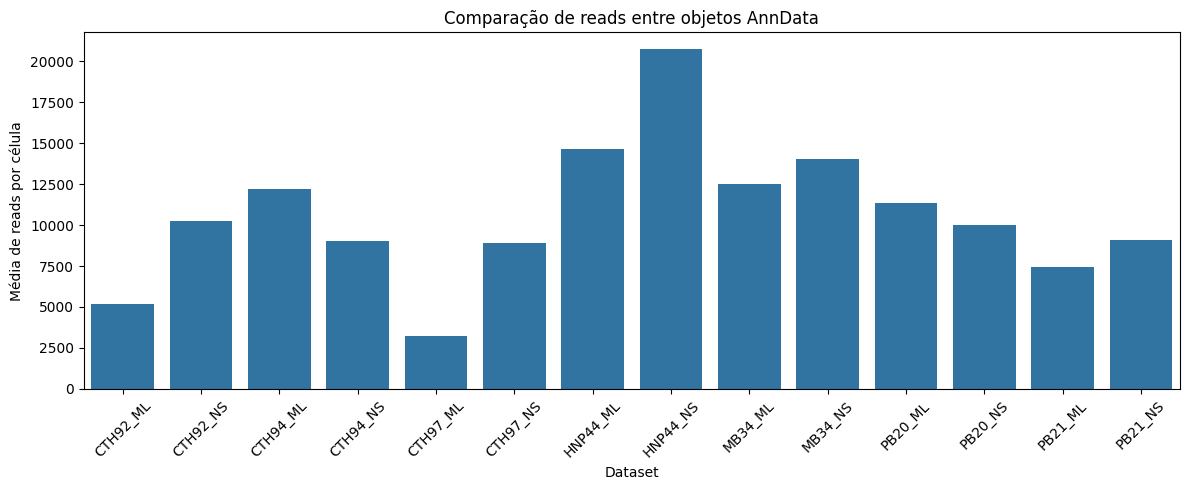

In [5]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Lista contendo os 14 objetos AnnData
# adatas = [adata1, adata2, ..., adata14]

# -----------------------------
# Resumo de reads por objeto
# -----------------------------

summary = []

for i, adata in enumerate(adatas):
    
    # Número total de reads por célula
    total_reads_per_cell = np.array(adata.X.sum(axis=1)).flatten()
    
    # Número total de reads no objeto
    total_reads = total_reads_per_cell.sum()
    
    # Estatísticas
    summary.append({
        "dataset": f"{pastas[i].split('.')[0]}",
        "n_cells": adata.n_obs,
        "n_genes": adata.n_vars,
        "total_reads": total_reads,
        "mean_reads_per_cell": total_reads_per_cell.mean(),
        "median_reads_per_cell": np.median(total_reads_per_cell),
        "min_reads_per_cell": total_reads_per_cell.min(),
        "max_reads_per_cell": total_reads_per_cell.max()
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

# -----------------------------
# Visualização
# -----------------------------

plt.figure(figsize=(12,5))

sns.barplot(
    data=summary_df,
    x="dataset",
    y="mean_reads_per_cell"
)

plt.xticks(rotation=45)
plt.ylabel("Média de reads por célula")
plt.xlabel("Dataset")
plt.title("Comparação de reads entre objetos AnnData")

plt.tight_layout()
plt.show()

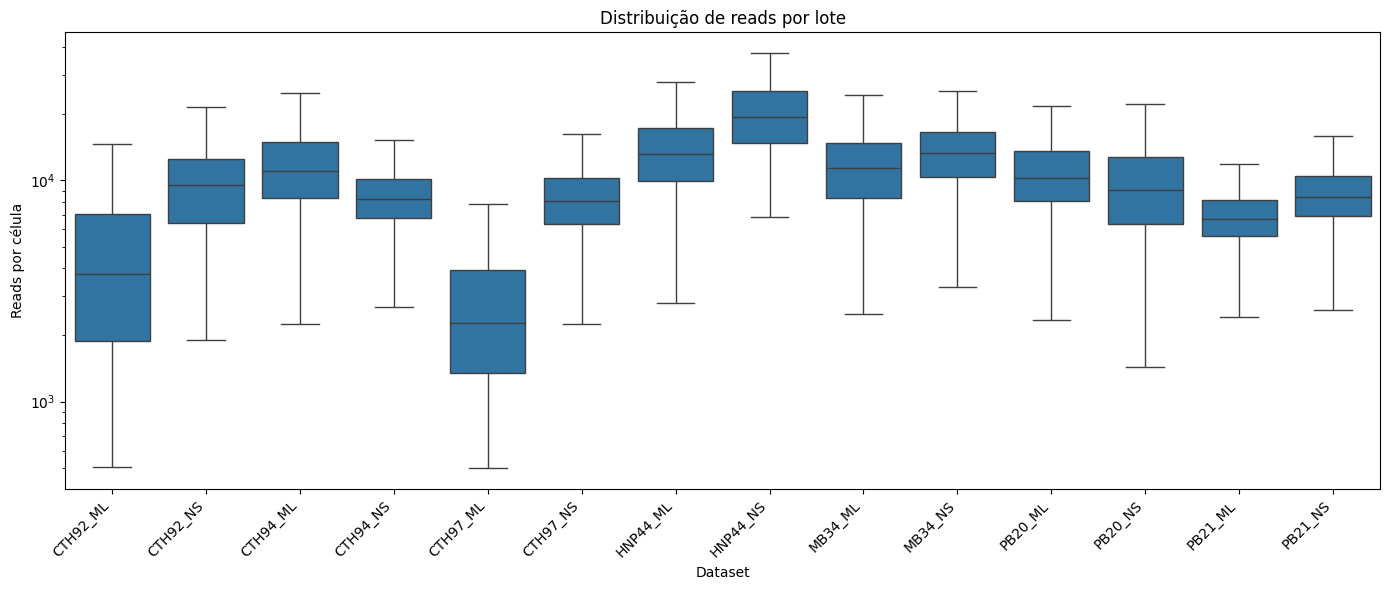

In [6]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Preparar dados para boxplot
# -----------------------------

boxplot_data = []

for i, adata in enumerate(adatas):
    
    # Reads totais por célula
    total_reads_per_cell = np.array(adata.X.sum(axis=1)).flatten()
    
    # Criar dataframe temporário
    temp_df = pd.DataFrame({
        "dataset": f"{pastas[i].split('.')[0]}",
        "reads_per_cell": total_reads_per_cell
    })
    
    boxplot_data.append(temp_df)

# Concatenar todos os datasets
boxplot_df = pd.concat(boxplot_data, ignore_index=True)

# -----------------------------
# Boxplot
# -----------------------------

plt.figure(figsize=(14,6))

sns.boxplot(
    data=boxplot_df,
    x="dataset",
    y="reads_per_cell",
    showfliers=False  # remove outliers extremos do gráfico
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Reads por célula")
plt.xlabel("Dataset")
plt.title("Distribuição de reads por lote")

# Opcional: escala log
plt.yscale("log")

plt.tight_layout()
plt.show()

In [7]:
print(f"ENSG genes: {len([i for i in adata.var['gene_symbols'] if i.startswith('ENSG')])}")
print(f"Symbol genes: {len([i for i in adata.var['gene_symbols'] if not i.startswith('ENSG')])}")
print(f"Total genes: {len([i for i in adata.var['gene_symbols']])}")

ENSG genes: 7275
Symbol genes: 20520
Total genes: 27795


In [8]:
import anndata as an
bdata = an.concat(adatas[0:], join="inner", fill_value = 0, uns_merge="first", label= "library_id", keys= [i.replace(".h5ad", "") for i in pastas])
bdata.obs_names_make_unique()

/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
bdata.var_names_make_unique()

In [10]:
bdata.write_h5ad(os.path.join(notebookPath, "data",  "integratedFiltered.h5ad"))

# Dado Mergido

In [11]:
import scanpy as sc 
import os

notebookPath = os.path.dirname(os.path.dirname(os.getcwd()))

bdata = sc.read(os.path.join(notebookPath, "data", "integratedFiltered.h5ad"))
bdata.obs_names_make_unique()

In [12]:
list(bdata.obs["library_id"].unique())

['CTH92_ML',
 'CTH92_NS',
 'CTH94_ML',
 'CTH94_NS',
 'CTH97_ML',
 'CTH97_NS',
 'HNP44_ML',
 'HNP44_NS',
 'MB34_ML',
 'MB34_NS',
 'PB20_ML',
 'PB20_NS',
 'PB21_ML',
 'PB21_NS']

In [13]:
bdata.obs["controles"] = [
    "controle" if i.startswith("CTH") else "estudo"
    for i in bdata.obs["library_id"]
]

bdata.obs["classificacao"] = [
    "PB" if i.startswith("PB")
    else "controle" if i.startswith("CTH")
    else "MB"
    for i in bdata.obs["library_id"]
]

bdata.obs["estimulo"] = [
    "nao estimulado" if i.endswith("NS") else "estimulado"
    for i in bdata.obs["library_id"]
]

In [14]:
print(bdata.obs["classificacao"].unique())
print(bdata.obs["controles"].unique())
print(bdata.obs["estimulo"].unique())

['controle' 'MB' 'PB']
['controle' 'estudo']
['estimulado' 'nao estimulado']


In [15]:
print('---------------------')
print(bdata.obs["classificacao"].value_counts())
print('---------------------')
print('---------------------')
print(bdata.obs["controles"].value_counts())
print('---------------------')
print('---------------------')
print(bdata.obs["estimulo"].value_counts())
print('---------------------')


---------------------
classificacao
PB          15623
controle    14545
MB           4763
Name: count, dtype: int64
---------------------
---------------------
controles
estudo      20386
controle    14545
Name: count, dtype: int64
---------------------
---------------------
estimulo
estimulado        20850
nao estimulado    14081
Name: count, dtype: int64
---------------------


/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/spatools/plotting/pl.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = adata.obs.groupby([group_by, clusters_col]).size().unstack(fill_value=0)# type: ignore


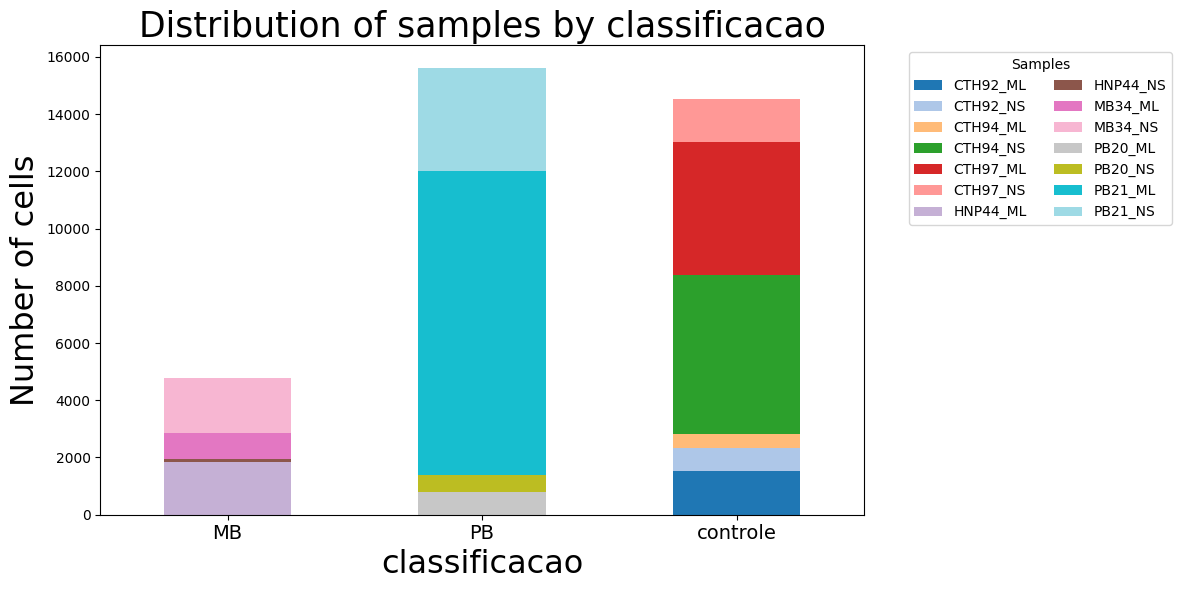

In [16]:
import spatools as st
st.pl.bar(
    adata=bdata,
    clusters_col="library_id",
    group_by="classificacao",
    title="Distribution of samples by classificacao",
    xlabel="classificacao",
    ylabel="Number of cells",
    use_percentage=False, 
    angle=0,
    legend="Samples"
)

/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/spatools/plotting/pl.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = adata.obs.groupby([group_by, clusters_col]).size().unstack(fill_value=0)# type: ignore


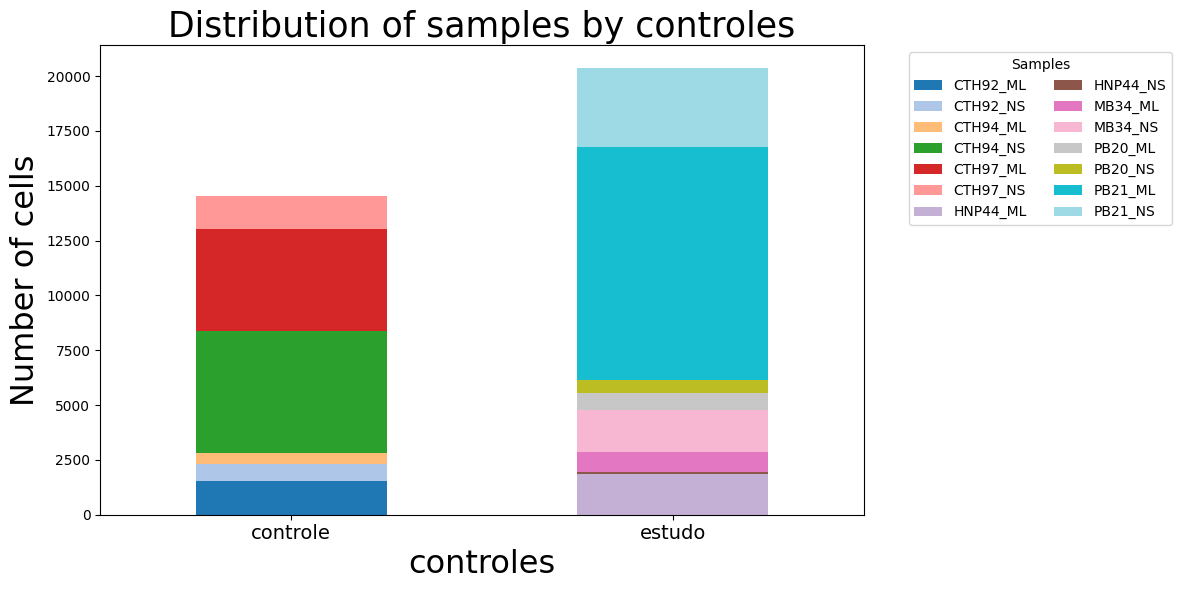

In [17]:
import spatools as st
st.pl.bar(
    adata=bdata,
    clusters_col="library_id",
    group_by="controles",
    title="Distribution of samples by controles",
    xlabel="controles",
    ylabel="Number of cells",
    use_percentage=False, 
    angle=0,
    legend="Samples"
)

/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/spatools/plotting/pl.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = adata.obs.groupby([group_by, clusters_col]).size().unstack(fill_value=0)# type: ignore


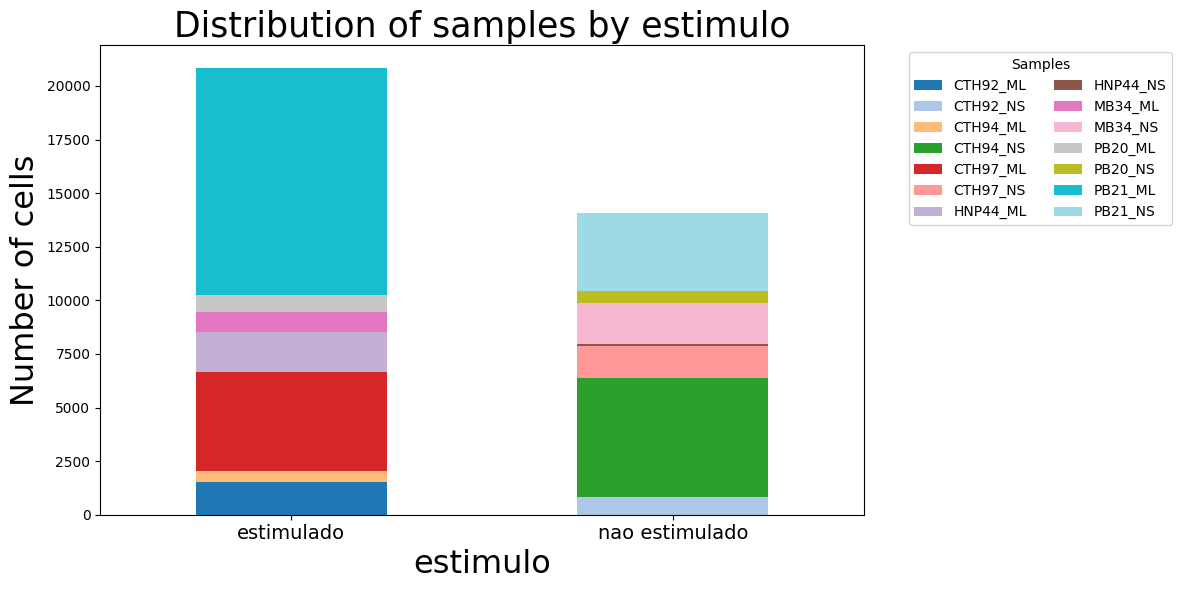

In [18]:
import spatools as st
st.pl.bar(
    adata=bdata,
    clusters_col="library_id",
    group_by="estimulo",
    title="Distribution of samples by estimulo",
    xlabel="estimulo",
    ylabel="Number of cells",
    use_percentage=False, 
    angle=0,
    legend="Samples"
)

# comecando a integracao

In [19]:
from copy import deepcopy
bdata.layers["counts"] = deepcopy(bdata.X)

In [20]:
len([i for i in bdata.var_names if i.startswith('ENSG')])

17761

In [21]:
bdata.var_names_make_unique()
bdata.obs_names_make_unique()

In [22]:
bdata = st.tl.translate_anndata_genes(adata=bdata)

10 input query terms found dup hits:	[('ENSG00000291072', 2), ('ENSG00000234162', 2), ('ENSG00000227110', 2), ('ENSG00000243620', 2), ('E
213 input query terms found no hit:	['ENSG00000238009', 'ENSG00000291215', 'ENSG00000290784', 'ENSG00000236948', 'ENSG00000226849', 'ENS


In [23]:
print(f"ENSG genes: {len([i for i in bdata.var_names if not i.startswith('ENSG')])}")
print(f"symbol genes: {len([i for i in bdata.var_names if i.startswith('ENSG')])}")

ENSG genes: 15447
symbol genes: 2314


In [24]:
bdata.var

,gene_ids,gene_symbol
ENSG00000238009,ENSG00000238009,ENSG00000238009
ENSG00000241860,ENSG00000241860,ENSG00000241860
ENSG00000290385,ENSG00000290385,ENSG00000290385
ENSG00000291215,ENSG00000291215,ENSG00000291215
LINC01409,ENSG00000237491,LINC01409
...,...,...
MT-ND6,ENSG00000198695,MT-ND6
MT-CYB,ENSG00000198727,MT-CYB
MAFIP,ENSG00000274847,MAFIP
ENSG00000273748,ENSG00000273748,ENSG00000273748


In [25]:
import scanpy as sc

# genes mitocondriais
bdata.var["mt"] = bdata.var_names.str.startswith("MT-")

# genes ribossomais
bdata.var["rps"] = bdata.var_names.str.startswith("RPS")
bdata.var["rpl"] = bdata.var_names.str.startswith("RPL")

# calcular QC metrics
sc.pp.calculate_qc_metrics(
    bdata,
    qc_vars=["mt", "rps", "rpl"],
    inplace=True
)

In [26]:
sc.experimental.pp.normalize_pearson_residuals(bdata)

sc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=5000,
    batch_key="library_id",
    layer="counts",
    subset=False
)

In [27]:
len([i for i in bdata.var['rpl'] if i])

55

In [46]:
bdata_hvg = bdata[:, bdata.var['highly_variable']].copy()

In [47]:
bdata_hvg

AnnData object with n_obs × n_vars = 34931 × 5000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'library_id', 'controles', 'classificacao', 'estimulo', 'total_counts_rps', 'log1p_total_counts_rps', 'pct_counts_rps', 'total_counts_rpl', 'log1p_total_counts_rpl', 'pct_counts_rpl'
    var: 'gene_ids', 'gene_symbol', 'mt', 'rps', 'rpl', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'neighbors', 'pca', 'predicted_doublet_colors', 'preprocessing_stats_CTH92_ML', 'preprocessing_stats_CTH92_NS', 'preprocessing_stats_CTH94_ML

# Benchmark de Integração (scib)

Métodos testados: **Harmony**, **scVI**, **Scanorama**, **BBKNN**, **scGEN**, **Seurat v3 CCA**, **Seurat v3 RPCA**, **ComBat** e **MNN**.

> **Nota sobre métodos extras:** além dos solicitados, incluímos **ComBat** (robusto para correção de batch linear, muito usado em dados de citometria/bulk adaptados para scRNA) e **MNN** (Mutual Nearest Neighbours, baseline sólido e interpretável). Ambos complementam bem o painel, especialmente para comparar métodos lineares vs não-lineares no seu contexto de PB/MB/controle.

In [48]:
import scanpy as sc
import numpy as np
import pandas as pd
import scib
import warnings
from copy import deepcopy
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────
# 1. Recriar objeto limpo a partir dos counts brutos
#    (necessário: scib exige counts originais em .layers["counts"])
# ──────────────────────────────────────────────────────────────
adata_bench = sc.AnnData(
    X=bdata_hvg.layers["counts"].copy(),
    obs=bdata_hvg.obs[["library_id", "controles", "classificacao", "estimulo"]].copy(),
    var=bdata_hvg.var[["mt", "rps", "rpl"]].copy()
)
adata_bench.layers["counts"] = adata_bench.X.copy()

# PCA
sc.tl.pca(adata_bench)

# Parâmetros globais do benchmark
BATCH_KEY  = "library_id"
LABEL_KEY  = "classificacao"   # PB / MB / controle
N_NEIGHBORS = 15

print(adata_bench)


AnnData object with n_obs × n_vars = 34931 × 5000
    obs: 'library_id', 'controles', 'classificacao', 'estimulo'
    var: 'mt', 'rps', 'rpl'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'


In [49]:
import scib

In [66]:
sca_adata = scib.ig.runScanvi(adata_bench, batch="library_id")

TypeError: scanvi() missing 1 required positional argument: 'labels'

In [52]:
sca_adata = scib.ig.runScanorama(adata_bench, batch="library_id")

Found 5000 genes among all datasets
[[0.         0.47466007 0.36895161 0.26789232 0.09192383 0.03328895
  0.20420223 0.06493506 0.32138979 0.1103086  0.11583012 0.0910596
  0.19697965 0.09520683]
 [0.         0.         0.34879032 0.63535229 0.05191595 0.07292954
  0.37577256 0.24675325 0.16720955 0.17552534 0.08236808 0.07119205
  0.19777503 0.15451174]
 [0.         0.         0.         0.60887097 0.11693548 0.05040323
  0.49798387 0.14285714 0.08469055 0.14516129 0.10887097 0.04435484
  0.19354839 0.0766129 ]
 [0.         0.         0.         0.         0.04101353 0.4713715
  0.44701452 0.5974026  0.10966341 0.22035677 0.1029601  0.12582781
  0.17866139 0.10841379]
 [0.         0.         0.         0.         0.         0.23834887
  0.05648198 0.02597403 0.25841477 0.03252886 0.12097812 0.0794702
  0.23405626 0.08245652]
 [0.         0.         0.         0.         0.         0.
  0.1517976  0.28571429 0.01194354 0.1045273  0.05858855 0.04801325
  0.38948069 0.23302264]
 [0.     

In [65]:
sca_adata.write_h5ad('/mnt/SATA/singleCellTaru/data/adata_scanorama.h5ad')

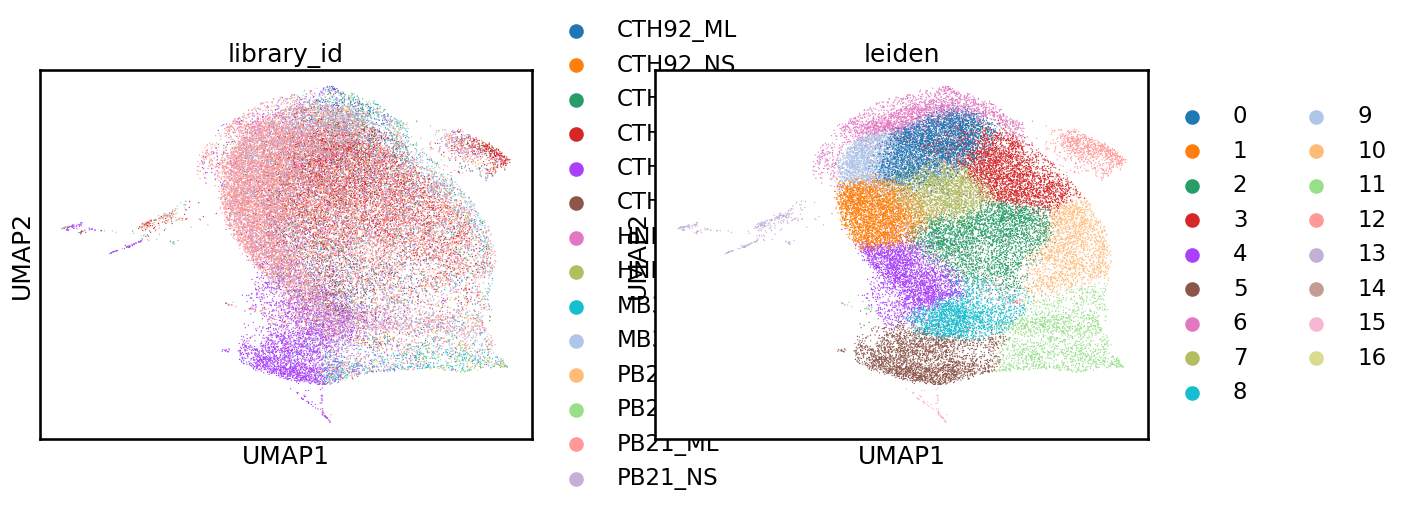

In [ ]:
sca_adata.obsm["X_emb"]

sc.pp.neighbors(sca_adata, use_rep="X_emb")
sc.tl.umap(sca_adata)
sc.tl.leiden(sca_adata)

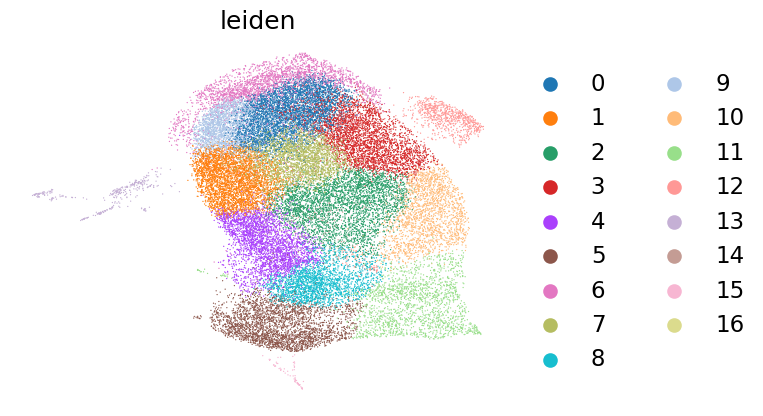

In [60]:
sc.pl.umap(sca_adata, color=["leiden"], frameon=False)

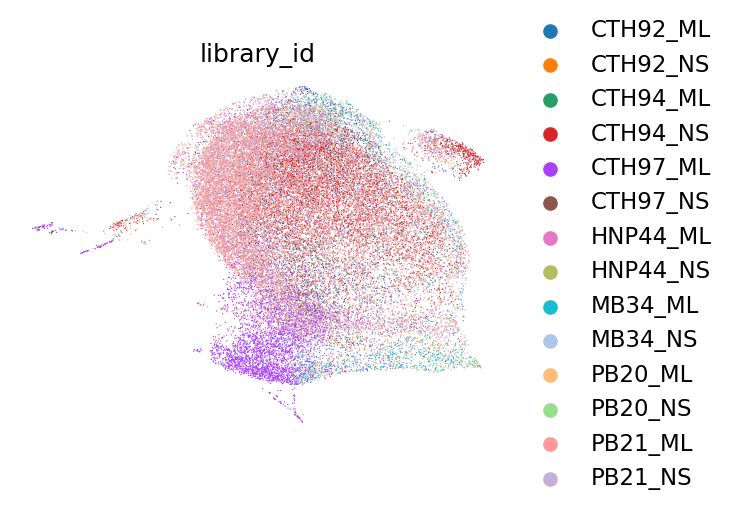

In [ ]:
sc.pl.umap(sca_adata, color=["library_id"], frameon=False)

In [62]:
adata_bench.obsm["X_pca"]

array([[-2.85607697e+02,  1.22622976e+01,  6.16587102e-01, ...,
         1.56145430e+00,  1.30202389e+00, -4.57556427e-01],
       [-1.84898682e+02,  5.59434080e+00,  3.13236266e-02, ...,
        -4.02953625e-01,  2.65753698e+00,  7.37995744e-01],
       [-2.70285980e+02,  1.12828169e+01,  5.37340820e-01, ...,
        -8.72262061e-01,  1.72837102e+00,  8.32377434e-01],
       ...,
       [ 1.34100189e+02, -1.42991476e+01, -1.60969150e+00, ...,
        -1.43135715e+00,  5.74110079e+00,  6.16205978e+00],
       [ 1.26446754e+02, -1.38695383e+01, -2.56424236e+00, ...,
        -3.39065766e+00,  1.26861382e+00,  4.82680798e+00],
       [-1.44010086e+02,  7.45327187e+00,  2.36634159e+00, ...,
         1.14184034e+00,  1.97714877e+00, -5.98484635e-01]],
      shape=(34931, 50), dtype=float32)

In [63]:
print(adata_bench.obsm["X_pca"].shape)
print(adata_bench.n_obs)

(34931, 50)
34931


In [32]:
import harmonypy as hm
import numpy as np

adata_harmony = adata_bench.copy()

ho = hm.run_harmony(
    np.asarray(adata_harmony.obsm["X_pca"]),
    adata_harmony.obs,
    BATCH_KEY
)

adata_harmony.obsm["X_emb_harmony"] = np.asarray(ho.Z_corr)

sc.pp.neighbors(
    adata_harmony,
    use_rep="X_emb_harmony",
    n_neighbors=N_NEIGHBORS
)

sc.tl.umap(adata_harmony)
sc.tl.leiden(adata_harmony, resolution=0.5)

print("Harmony OK")

2026-06-07 16:34:47,677 - harmonypy - INFO - Running Harmony
2026-06-07 16:34:47,678 - harmonypy - INFO -   Parameters:
2026-06-07 16:34:47,678 - harmonypy - INFO -     max_iter_harmony: 10
2026-06-07 16:34:47,678 - harmonypy - INFO -     max_iter_kmeans: 4
2026-06-07 16:34:47,679 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-06-07 16:34:47,679 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-06-07 16:34:47,679 - harmonypy - INFO -     nclust: 100
2026-06-07 16:34:47,679 - harmonypy - INFO -     block_size: 0.05
2026-06-07 16:34:47,679 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-06-07 16:34:47,680 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-06-07 16:34:47,680 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-07 16:34:47,680 - harmonypy - INFO -     verbose: True
2026-06-07 16:34:47,680 - harmonypy - INFO -     random_state: 0
2026-06-07 16:34:47,680 - harmonypy - INFO -   Data: 50 PCs × 34931 cells
2026-06-07 16:

Harmony OK


In [33]:
adata_harmony

AnnData object with n_obs × n_vars = 34931 × 17761
    obs: 'library_id', 'controles', 'classificacao', 'estimulo', 'leiden'
    var: 'mt', 'rps', 'rpl'
    uns: 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_emb_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
import os

caminho = os.path.dirname(os.path.dirname(os.getcwd()))

adata_harmony.write_h5ad(filename=os.path.join(caminho, "data", "adata_harmony.h5ad"))

In [1]:
import scanpy as sc
import scib
import os
data = os.path.dirname(os.path.dirname(os.getcwd()))

# adata_bbknn = sc.read_h5ad(os.path.join(data, "data/adata_bbknn.h5ad"))
adata_harmony = sc.read_h5ad(os.path.join(data,"data/adata_harmony.h5ad"))
# adata_scanorama = sc.read_h5ad(os.path.join(data,"data/adata_scanorama.h5ad"))
adata_scvi = sc.read_h5ad(os.path.join(data, "data/adata_scvi.h5ad"))

In [3]:
for ad in [adata_harmony, adata_scvi]:
    ad.obs["batch"] = ad.obs["library_id"]
    # ajuste se o nome for diferente:
    # ad.obs["cell_type"] = ad.obs["leiden"]

In [4]:
adatas = {
    # "BBKNN": adata_bbknn,
    "Harmony": adata_harmony,
    # "Scanorama": adata_scanorama,
    "scVI": adata_scvi
}

In [5]:
for ad in adatas.values():
    ad.obs["dummy"] = "dummy"
    ad.obs["dummy"] = ad.obs["dummy"].astype("category")

In [6]:
!export R_LIBS_USER=/home/pedrovp/R/x86_64-pc-linux-gnu-library/4.6

In [ ]:
import scib
import pandas as pd

results = {}

for name, ad in adatas.items():
    print(f"Rodando métricas de batch para {name}...")

    res = scib.metrics.metrics(
        adata=ad,
        adata_int=ad,
        batch_key="batch",

        # ❌ desligar tudo que precisa de cell_type
        label_key="dummy",
        ari_=False,
        nmi_=False,
        silhouette_=False,
        isolated_labels_asw_=False,
        isolated_labels_=False,
        isolated_labels_f1_=False,

        # ✅ manter métricas de batch
        graph_conn_=True,
        pcr_=True,
        kBET_=True,

        # embedding (ajuste por método)
        embed=None  # vamos tratar isso abaixo
    )

    results[name] = res

Rodando métricas de batch para Harmony...
PC regression...
Graph connectivity...
kBET...


/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)


Adding diffusion to step 2
Adding diffusion to step 3


/mnt/SATA/singleCellTaru/.venv/lib/python3.11/site-packages/scib/metrics/kbet.py:111: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_tmp.obs.groupby(label_key).agg(


0 labels consist of a single batch or is too small. Skip.


In [ ]:
embeddings = {
    "BBKNN": None,              # usa grafo
    "Harmony": "X_pca_harmony",
    "Scanorama": "X_emb",       # ou X_scanorama
    "scVI": "X_scVI"
}

In [ ]:
df = pd.DataFrame(results).T
print(df)

Empty DataFrame
Columns: []
Index: []


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(df, annot=True, cmap="viridis")
plt.title("Batch correction metrics (scIB)")
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 800x500 with 0 Axes>

In [ ]:
pcs_range = [10, 20, 30, 40, 50]

results = []

for n_pcs in pcs_range:
    sc.pp.neighbors(adata, n_pcs=n_pcs)
    
    score = scib.metrics.metrics(
        adata=adata,
        adata_int=adata,
        batch_key="batch",
        label_key="cell_type",
        embed="X_pca"
    )
    
    results.append((n_pcs, score["overall"]))

print(sorted(results, key=lambda x: -x[1]))